## Curate epithelium patches from BReAst Carcinoma Subtyping (BRACS) database (https://www.bracs.icar.cnr.it/) 

In [17]:
import os
import pandas as pd
import numpy as np
import openslide
import matplotlib.pyplot as plt
import glob
import cv2
from pathlib import Path
from PIL import Image
import random
import staintools

def extract_patch_ids_per_ROI(image_pt=None, patch_size=1024, center_region_size=256, max_total_attempts=30):
    existing_patch_ids = set()
    patch_infos = []
    total_attempts = 0
    
    roi_image = Image.open(image_pt)
    roi_id = os.path.basename(image_pt).split('.png')[0]
    source = roi_id.split("_")[-2]

    roi_array = np.array(roi_image)
    h, w = roi_array.shape[:2]
    
    # Check if ROI is large enough
    if w < patch_size or h < patch_size:
        print(f"ROI too small ({w}x{h}) for extracting {patch_size}x{patch_size} patch")
        return pd.DataFrame()
    
    center_x, center_y = w // 2, h // 2
    
    # Use center_region_size parameter
    half_center = center_region_size // 2
    center_left = max(patch_size // 2, center_x - half_center)
    center_right = min(w - patch_size // 2, center_x + half_center)
    center_top = max(patch_size // 2, center_y - half_center)
    center_bottom = min(h - patch_size // 2, center_y + half_center)
    
    if center_left >= center_right:
        center_left = patch_size // 2
        center_right = w - patch_size // 2
    
    if center_top >= center_bottom:
        center_top = patch_size // 2
        center_bottom = h - patch_size // 2
    
    if center_left >= center_right or center_top >= center_bottom:
        print(f"⚠️ ROI {roi_id} cannot safely sample from center region, skipping")
        return pd.DataFrame()
    
    print(f"ROI: {roi_id}, dimensions: {w}x{h}")
    print(f"Sampling area: ({center_left}-{center_right}, {center_top}-{center_bottom})")
    print(f"Sampling range: {center_right-center_left}x{center_bottom-center_top}")
    
    while total_attempts < max_total_attempts:
        rand_center_x = random.randint(center_left, center_right - 1)
        rand_center_y = random.randint(center_top, center_bottom - 1)
        
        half_patch = patch_size // 2
        patch_left = rand_center_x - half_patch
        patch_top = rand_center_y - half_patch
        
        patch_id = f"{roi_id}_{patch_left}_{patch_top}_{patch_size}"
        
        if patch_id not in existing_patch_ids:
            existing_patch_ids.add(patch_id)
            patch_info = {
                'patch_id': patch_id,
                'roi_id': roi_id,
                'source': source,
                'x': patch_left,
                'y': patch_top,
                'size': patch_size,
                'center_x': rand_center_x,
                'center_y': rand_center_y
            }
            patch_infos.append(patch_info)
        
        total_attempts += 1

    return pd.DataFrame(patch_infos)

In [ ]:
basefolder="/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTClassifier/npj_revision"
image_folder = '/scratch/prj/cb_normalbreast/prj_BreastAgeNet/WSIs/BRACS_ROI'
os.listdir(image_folder+'/train')

In [26]:
image_pts = glob.glob(f"{image_folder}/*/*/*.png")
print(len(image_pts))
image_pts[-6:]

4539


['/scratch/prj/cb_normalbreast/prj_BreastAgeNet/WSIs/BRACS_ROI/test/5_DCIS/BRACS_292_DCIS_23.png',
 '/scratch/prj/cb_normalbreast/prj_BreastAgeNet/WSIs/BRACS_ROI/test/5_DCIS/BRACS_292_DCIS_21.png',
 '/scratch/prj/cb_normalbreast/prj_BreastAgeNet/WSIs/BRACS_ROI/test/5_DCIS/BRACS_1602_DCIS_3.png',
 '/scratch/prj/cb_normalbreast/prj_BreastAgeNet/WSIs/BRACS_ROI/test/5_DCIS/BRACS_286_DCIS_6.png',
 '/scratch/prj/cb_normalbreast/prj_BreastAgeNet/WSIs/BRACS_ROI/test/5_DCIS/BRACS_292_DCIS_10.png',
 '/scratch/prj/cb_normalbreast/prj_BreastAgeNet/WSIs/BRACS_ROI/test/5_DCIS/BRACS_1872_DCIS_4.png']

In [ ]:
patch_ids_df = []
failed_rois = []
for i, image_pt in enumerate(image_pts):
    print(f"Processing {i+1}/{len(image_pts)} ROI: {os.path.basename(image_pt)}")
    try:
        dfi = extract_patch_ids_per_ROI(
            image_pt=image_pt, 
            patch_size=1024, 
            center_region_size=256, 
            max_total_attempts=30
        )
        if not dfi.empty:
            patch_ids_df.append(dfi)
        else:
            failed_rois.append(os.path.basename(image_pt))
    except Exception as e:
        print(f"Error processing {os.path.basename(image_pt)}: {e}")
        failed_rois.append(os.path.basename(image_pt))
        continue

if patch_ids_df:
    final_patch_ids_df = pd.concat(patch_ids_df, ignore_index=True)
    print(f"Successfully processed: {len(final_patch_ids_df)} patches from {len(patch_ids_df)} ROIs")
else:
    final_patch_ids_df = pd.DataFrame()
    print("No patch information obtained")

if failed_rois:
    print(f"Failed ROIs ({len(failed_rois)}): {failed_rois}")

In [124]:
final_patch_ids_df.to_csv(f"{basefolder}/BRACS_patch_ids_CenterSampling.csv", index=False)
final_patch_ids_df

,patch_id,roi_id,source,x,y,size,center_x,center_y
0,BRACS_1811_UDH_28_305_169_1024,BRACS_1811_UDH_28,UDH,305,169,1024,817,681
1,BRACS_1811_UDH_28_346_87_1024,BRACS_1811_UDH_28,UDH,346,87,1024,858,599
2,BRACS_1811_UDH_28_332_74_1024,BRACS_1811_UDH_28,UDH,332,74,1024,844,586
3,BRACS_1811_UDH_28_205_74_1024,BRACS_1811_UDH_28,UDH,205,74,1024,717,586
4,BRACS_1811_UDH_28_230_20_1024,BRACS_1811_UDH_28,UDH,230,20,1024,742,532
...,...,...,...,...,...,...,...,...
91551,BRACS_1872_DCIS_4_327_934_1024,BRACS_1872_DCIS_4,DCIS,327,934,1024,839,1446
91552,BRACS_1872_DCIS_4_178_898_1024,BRACS_1872_DCIS_4,DCIS,178,898,1024,690,1410
91553,BRACS_1872_DCIS_4_376_893_1024,BRACS_1872_DCIS_4,DCIS,376,893,1024,888,1405
91554,BRACS_1872_DCIS_4_237_828_1024,BRACS_1872_DCIS_4,DCIS,237,828,1024,749,1340


In [125]:
print(np.unique(final_patch_ids_df['source'], return_counts=True))

(array(['ADH', 'DCIS', 'FEA', 'IC', 'N', 'PB', 'UDH'], dtype=object), array([ 8363, 18863,  8056, 17514, 10581, 19851,  8328]))


In [126]:
# sample 8000 per class
sampled_df = (
    final_patch_ids_df.groupby("source", group_keys=False)
    .apply(lambda x: x.sample(n=8000, random_state=42) if len(x) >= 8000 else x)
)
print(np.unique(sampled_df['source'], return_counts=True))

sampled_df.to_csv(f"{basefolder}/BRACS_patch_ids_CenterSampling_sampled8000.csv", index=False)

/tmp/ipykernel_2594662/630810643.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_patch_ids_df.groupby("source", group_keys=False)


(array(['ADH', 'DCIS', 'FEA', 'IC', 'N', 'PB', 'UDH'], dtype=object), array([8000, 8000, 8000, 8000, 8000, 8000, 8000]))


In [127]:
sampled_df

,patch_id,roi_id,source,x,y,size,center_x,center_y
16869,BRACS_1933_ADH_15_480_1126_1024,BRACS_1933_ADH_15,ADH,480,1126,1024,992,1638
77401,BRACS_1607_ADH_7_5_327_1024,BRACS_1607_ADH_7,ADH,5,327,1024,517,839
84703,BRACS_1580_ADH_14_31_636_1024,BRACS_1580_ADH_14,ADH,31,636,1024,543,1148
19100,BRACS_1934_ADH_9_4_80_1024,BRACS_1934_ADH_9,ADH,4,80,1024,516,592
77452,BRACS_1395_ADH_3_104_180_1024,BRACS_1395_ADH_3,ADH,104,180,1024,616,692
...,...,...,...,...,...,...,...,...
82217,BRACS_1944_UDH_1_354_363_1024,BRACS_1944_UDH_1,UDH,354,363,1024,866,875
75836,BRACS_265_UDH_19_1630_1157_1024,BRACS_265_UDH_19,UDH,1630,1157,1024,2142,1669
82971,BRACS_1503_UDH_14_745_177_1024,BRACS_1503_UDH_14,UDH,745,177,1024,1257,689
4893,BRACS_1810_UDH_7_12_468_1024,BRACS_1810_UDH_7,UDH,12,468,1024,524,980


## Feature extraction by the 1024px-based NBT-Classifier: see BRACS_TC1024.py

## Feature extraction by histoROI: see BRACS_histoROI.py

## Comparative Analysis of Epithelial Probabilities across Breast Tissue Categories: histoROI versus TC1024

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import matplotlib as mpl
import os
import numpy as np
import openslide
from scipy.stats import gaussian_kde
from scipy.integrate import quad
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc
from scipy.stats import norm

mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['pdf.fonttype'] = 42  # TrueType 字体，可在 Illustrator 编辑
mpl.rcParams['ps.fonttype'] = 42


def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    mask_normal = (df[column] >= lower_bound) & (df[column] <= upper_bound)
    df_clean = df[mask_normal].copy()
    
    outliers = df[~mask_normal]

    return df_clean, outliers.index.tolist()



def compute_auc(df, value_col, lesion_types):
    results = []
    for lesion in lesion_types:
        # 仅保留N和目标病变类型
        mask = df['source'].isin(['N', lesion])
        df_subset = df[mask].copy()

        # 去除异常值，取返回的DataFrame部分
        df_n_clean = remove_outliers_iqr(df_subset[df_subset['source'] == 'N'], value_col)
        if isinstance(df_n_clean, tuple):
            df_n_clean = df_n_clean[0]

        df_lesion_clean = remove_outliers_iqr(df_subset[df_subset['source'] == lesion], value_col)
        if isinstance(df_lesion_clean, tuple):
            df_lesion_clean = df_lesion_clean[0]

        # 合并
        df_clean = pd.concat([df_n_clean, df_lesion_clean], ignore_index=True)

        # 转换标签和预测值
        y_true = df_clean['source'].map({'N': 1, lesion: 0}).values
        y_scores = df_clean[value_col].values

        # 计算AUC
        try:
            auc_score = roc_auc_score(y_true, y_scores)
            results.append({'Lesion_Type': lesion, 'AUC': auc_score})
        except Exception as e:
            results.append({'Lesion_Type': lesion, 'AUC': None})

    return pd.DataFrame(results)



def delong_test(y_true, y_scores1, y_scores2):
    n1, n0 = np.sum(y_true == 1), np.sum(y_true == 0)
    V1 = [np.mean(y_scores1[y_true == 0] < s) for s in y_scores1[y_true == 1]]
    V2 = [np.mean(y_scores2[y_true == 0] < s) for s in y_scores2[y_true == 1]]
    S = np.cov(V1, V2)
    se = np.sqrt((S[0,0] + S[1,1] - 2*S[0,1]) / (n0*n1))
    z = (roc_auc_score(y_true, y_scores1) - roc_auc_score(y_true, y_scores2)) / se
    p = 2 * (1 - norm.cdf(abs(z)))
    return z, p

In [2]:
# 1024px-based NBT-Classifier

basefolder="/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTClassifier/npj_revision"
df1 = pd.read_csv(f"{basefolder}/BRACS_patch_ids_overlap25_sampled3000_TC1024_batch0.csv")
df2 = pd.read_csv(f"{basefolder}/BRACS_patch_ids_overlap25_sampled3000_TC1024_batch1.csv")

TC1024_df = pd.concat([df1, df2], ignore_index=True)
print(len(TC1024_df))

epi_TC1024_df = TC1024_df[TC1024_df['cls'] == 'epithelium']
print(len(epi_TC1024_df))

print(f"{(len(epi_TC1024_df) / len(TC1024_df)) * 100:.2f}%")

56000
53836
96.14%


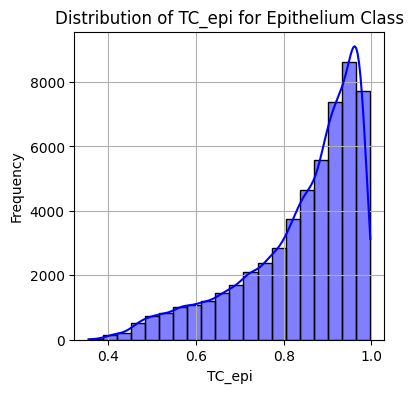

In [3]:
plt.figure(figsize=(4, 4))
sns.histplot(epi_TC1024_df['TC_epi'], bins=20, kde=True, color='blue')
plt.title('Distribution of TC_epi for Epithelium Class')
plt.xlabel('TC_epi')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [4]:
epi_TC1024_df['Group'] = epi_TC1024_df['source'].apply(lambda x: 'N' if x == 'N' else 'Rest')
df_n = epi_TC1024_df[epi_TC1024_df['Group'] == 'N'].copy()
df_rest = epi_TC1024_df[epi_TC1024_df['Group'] == 'Rest'].copy()

df_n_clean, n_outliers = remove_outliers_iqr(df_n, 'TC_epi')
df_rest_clean, rest_outliers = remove_outliers_iqr(df_rest, 'TC_epi')

df_clean = pd.concat([df_n_clean, df_rest_clean], ignore_index=True)
epi_TC1024_df = df_clean.copy()
epi_TC1024_df

/tmp/ipykernel_3921637/4175717275.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  epi_TC1024_df['Group'] = epi_TC1024_df['source'].apply(lambda x: 'N' if x == 'N' else 'Rest')


,patch_id,cls,TC_epi,TC_str,TC_adi,source,feature0,feature1,feature2,feature3,...,feature503,feature504,feature505,feature506,feature507,feature508,feature509,feature510,feature511,Group
0,BRACS_760_N_8_896_430_1024,epithelium,0.765560,0.146332,0.088109,N,0.060949,1.094974,0.008911,0.388103,...,1.236159,0.000000,0.340791,1.005583,0.0,0.077908,0.169719,0.086836,0.061010,N
1,BRACS_1585_N_2_182_165_1024,epithelium,0.952482,0.026463,0.021055,N,0.000000,1.182848,0.042903,0.000000,...,0.980574,0.254231,0.270685,0.984371,0.0,0.083451,0.222699,0.127893,0.000000,N
2,BRACS_1945_N_21_324_529_1024,epithelium,0.981025,0.006403,0.012572,N,0.034793,1.526606,0.491004,0.212279,...,0.865854,0.000000,0.225523,1.163352,0.0,0.095096,0.430448,0.060341,0.050752,N
3,BRACS_1937_N_6_217_0_1024,epithelium,0.899886,0.027420,0.072694,N,0.043148,1.341710,0.438936,0.158015,...,0.659320,0.102544,0.240274,0.517264,0.0,0.301437,0.151734,0.000000,0.089244,N
4,BRACS_1493_N_6_285_516_1024,epithelium,0.980827,0.006935,0.012239,N,0.219787,1.088240,0.000000,0.473845,...,0.974339,0.000000,0.353065,1.260775,0.0,0.427699,0.471838,0.222517,0.243144,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52292,BRACS_1944_UDH_1_354_363_1024,epithelium,0.958830,0.025450,0.015720,UDH,0.214734,1.161460,0.479189,0.286849,...,0.812526,0.305857,0.105614,0.952434,0.0,0.285229,0.000000,0.000000,0.151223,Rest
52293,BRACS_265_UDH_19_1630_1157_1024,epithelium,0.943635,0.027409,0.028957,UDH,0.000000,1.312894,0.507167,0.745634,...,0.746679,0.000000,0.000000,1.305341,0.0,0.494034,0.000000,0.000000,0.046250,Rest
52294,BRACS_1503_UDH_14_745_177_1024,epithelium,0.974746,0.005704,0.019550,UDH,0.000000,1.338505,0.715385,0.566624,...,1.207632,0.054681,0.295063,1.012749,0.0,0.420704,0.100061,0.000000,0.466232,Rest
52295,BRACS_1810_UDH_7_12_468_1024,epithelium,0.817711,0.065694,0.116595,UDH,0.102742,1.001682,0.315373,0.322322,...,1.068801,0.081082,0.533260,0.299801,0.0,0.301564,0.173305,0.000000,0.366836,Rest


/tmp/ipykernel_3921637/1099986676.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


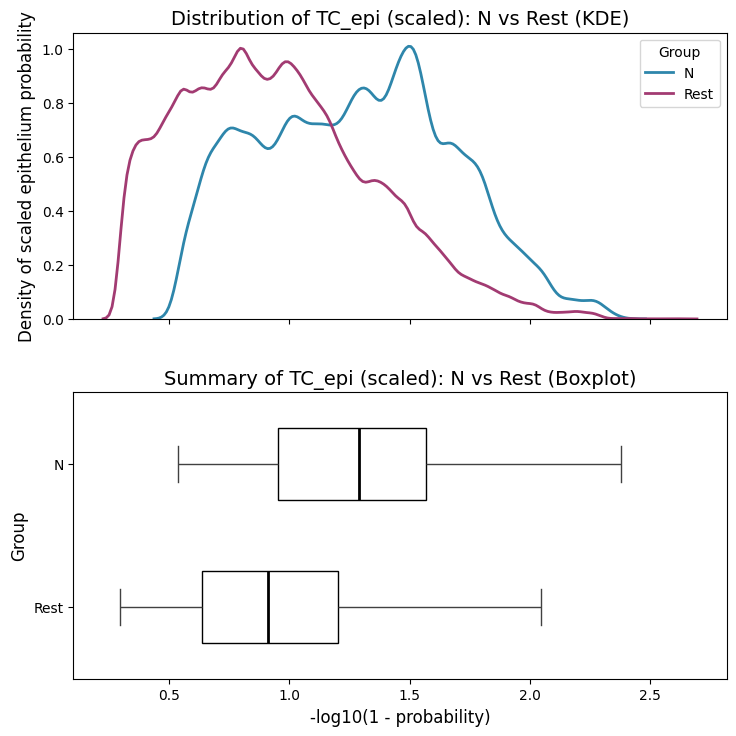

In [5]:
df_plot = epi_TC1024_df.copy()
df_plot['TC_epi_scaled'] = df_plot['TC_epi'].apply(lambda x: -np.log10(1 - x + 1e-10))  # 防止 log(0)

color_map = {'N': '#2E86AB', 'Rest': '#A23B72'}
group_order = ['N', 'Rest']


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
for group in group_order:
    subset = df_plot[df_plot['Group'] == group]['TC_epi_scaled']
    sns.kdeplot(
        subset, bw_adjust=0.5, color=color_map[group],
        linewidth=2, label=group, ax=ax1
    )
ax1.set_ylabel('Density of scaled epithelium probability', fontsize=12)
ax1.set_title('Distribution of TC_epi (scaled): N vs Rest (KDE)', fontsize=14)
ax1.legend(title='Group')


sns.boxplot(
    x='TC_epi_scaled', y='Group', data=df_plot,
    order=group_order,
    whis=1.5, width=0.5, showcaps=True,
    boxprops={'facecolor':'none', 'edgecolor':'black'},
    medianprops={'color':'black', 'linewidth':2},
    showfliers=False, orient='h', ax=ax2,
    palette=color_map
)
ax2.set_title('Summary of TC_epi (scaled): N vs Rest (Boxplot)', fontsize=14)
ax2.set_ylabel('Group', fontsize=12)
ax2.set_xlabel('-log10(1 - probability)', fontsize=12)

plt.tight_layout(pad=3.0)
plt.savefig(f"{basefolder}/BRACS_patch_ids_CenterSampling_sampled8000_TC1024_N_vs_Rest_scaled_density_boxplot.pdf",
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [6]:
# HistoROI
basefolder="/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTClassifier/npj_revision"
df1 = pd.read_csv(f"{basefolder}/BRACS_patch_ids_overlap25_sampled3000_histoROI_batch0.csv")
df2 = pd.read_csv(f"{basefolder}/BRACS_patch_ids_overlap25_sampled3000_histoROI_batch1.csv")
df3 = pd.read_csv(f"{basefolder}/BRACS_patch_ids_overlap25_sampled3000_histoROI_batch2.csv")
df4 = pd.read_csv(f"{basefolder}/BRACS_patch_ids_overlap25_sampled3000_histoROI_batch3.csv")

histoROI_df = pd.concat([df1, df2, df3, df4], ignore_index=True)
print(len(histoROI_df))

epi_histoROI_df = histoROI_df[histoROI_df['cls'] == 'Epithelial']
print(len(epi_histoROI_df))

print(f"{(len(epi_histoROI_df) / len(histoROI_df)) * 100:.2f}%")

56000
49585
88.54%


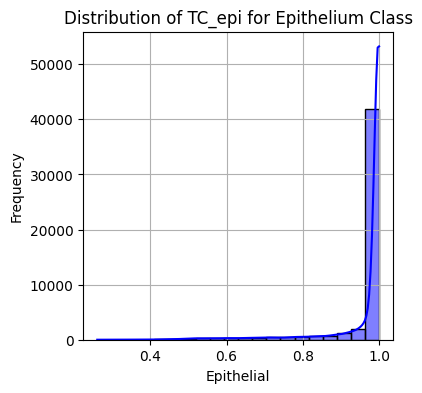

In [7]:
plt.figure(figsize=(4, 4))
sns.histplot(epi_histoROI_df['Epithelial'], bins=20, kde=True, color='blue')
plt.title('Distribution of TC_epi for Epithelium Class')
plt.xlabel('Epithelial')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [8]:
# 您的原始代码（修正版）
epi_histoROI_df['Group'] = epi_histoROI_df['source'].apply(lambda x: 'N' if x == 'N' else 'Rest')

df_n = epi_histoROI_df[epi_histoROI_df['Group'] == 'N'].copy()
df_rest = epi_histoROI_df[epi_histoROI_df['Group'] == 'Rest'].copy()

df_n_clean, n_outliers = remove_outliers_iqr(df_n, 'Epithelial')
df_rest_clean, rest_outliers = remove_outliers_iqr(df_rest, 'Epithelial')

df_clean = pd.concat([df_n_clean, df_rest_clean], ignore_index=True)
epi_histoROI_df = df_clean.copy()
epi_histoROI_df

/tmp/ipykernel_3921637/4282505043.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  epi_histoROI_df['Group'] = epi_histoROI_df['source'].apply(lambda x: 'N' if x == 'N' else 'Rest')


,patch_id,cls,Epithelial,Stroma,Adipose,Artefact,Miscellaneous,Lymphocytes,source,feature0,...,feature503,feature504,feature505,feature506,feature507,feature508,feature509,feature510,feature511,Group
0,BRACS_760_N_8_896_430_1024,Epithelial,0.999830,7.423428e-05,1.763677e-06,0.000026,0.000044,0.000023,N,3.186817,...,0.117160,1.329661,0.645336,1.792597,0.000000,0.009700,0.023814,3.545661,1.473098,N
1,BRACS_1945_N_21_324_529_1024,Epithelial,0.999989,7.097848e-07,3.652891e-08,0.000005,0.000004,0.000001,N,2.673697,...,0.049159,1.189896,0.956828,2.581498,0.011806,0.004808,0.468138,2.906716,1.993330,N
2,BRACS_1937_N_6_217_0_1024,Epithelial,0.999972,1.297250e-06,4.577699e-08,0.000022,0.000004,0.000001,N,2.793627,...,0.210281,1.629217,1.160518,2.837726,0.055023,0.000000,0.356836,3.701297,1.404939,N
3,BRACS_1493_N_6_285_516_1024,Epithelial,0.999250,1.382339e-05,6.442484e-06,0.000401,0.000259,0.000070,N,2.302839,...,0.315064,0.844833,0.988940,2.325733,0.147421,0.054502,0.502787,1.414004,0.935766,N
4,BRACS_1604_N_3_351_265_1024,Epithelial,0.999712,2.292572e-05,4.215221e-07,0.000168,0.000092,0.000005,N,1.653923,...,0.035227,0.450902,1.633207,2.774526,0.172269,0.005468,1.375690,1.484952,1.179506,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40527,BRACS_1617_UDH_11_251_175_1024,Epithelial,0.988009,2.194825e-03,1.018336e-04,0.006699,0.001585,0.001410,UDH,2.062324,...,0.264182,1.446796,0.588949,1.594006,0.280722,0.181813,0.524090,1.194366,1.469076,Rest
40528,BRACS_1944_UDH_1_354_363_1024,Epithelial,0.999211,2.660665e-05,3.264763e-06,0.000279,0.000421,0.000059,UDH,1.351822,...,0.117767,1.499105,0.793316,2.745703,0.150319,0.146509,0.153360,1.326453,0.969921,Rest
40529,BRACS_265_UDH_19_1630_1157_1024,Epithelial,0.998739,4.683976e-05,1.865389e-06,0.000353,0.000605,0.000254,UDH,4.194990,...,0.180660,1.599616,1.517509,0.986852,0.272967,0.040770,0.229518,2.378334,1.031048,Rest
40530,BRACS_1503_UDH_14_745_177_1024,Epithelial,0.985943,2.683432e-04,1.141782e-05,0.008605,0.001149,0.004023,UDH,2.455229,...,1.117314,1.106081,0.662090,2.186876,0.033193,0.034385,0.029156,1.528177,2.767821,Rest


/tmp/ipykernel_3921637/4057112645.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


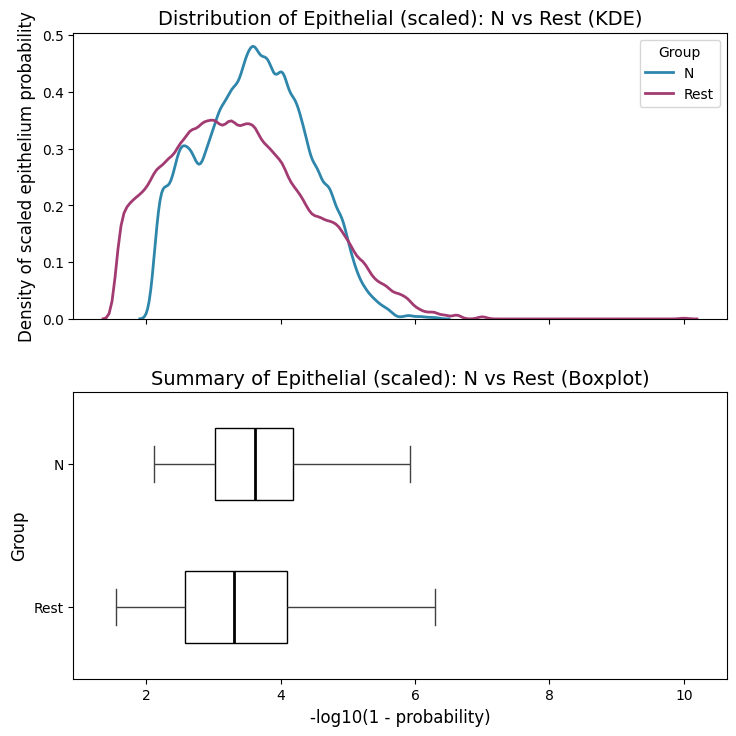

In [9]:
df_plot = epi_histoROI_df.copy()
df_plot['Epithelial_scaled'] = df_plot['Epithelial'].apply(lambda x: -np.log10(1 - x + 1e-10))  # 防止 log(0)

color_map = {'N': '#2E86AB', 'Rest': '#A23B72'}
group_order = ['N', 'Rest']


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
for group in group_order:
    subset = df_plot[df_plot['Group'] == group]['Epithelial_scaled']
    sns.kdeplot(
        subset, bw_adjust=0.5,
        color=color_map[group], linewidth=2,
        label=group, ax=ax1
    )
ax1.set_ylabel('Density of scaled epithelium probability', fontsize=12)
ax1.set_title('Distribution of Epithelial (scaled): N vs Rest (KDE)', fontsize=14)
ax1.legend(title='Group')


sns.boxplot(
    x='Epithelial_scaled', y='Group', data=df_plot,
    order=group_order,
    whis=1.5, width=0.5, showcaps=True,
    boxprops={'facecolor':'none', 'edgecolor':'black'},
    medianprops={'color':'black', 'linewidth':2},
    showfliers=False, orient='h', ax=ax2,
    palette=color_map
)
ax2.set_title('Summary of Epithelial (scaled): N vs Rest (Boxplot)', fontsize=14)
ax2.set_ylabel('Group', fontsize=12)
ax2.set_xlabel('-log10(1 - probability)', fontsize=12)

plt.tight_layout(pad=3.0)
plt.savefig(f"{basefolder}/BRACS_patch_ids_CenterSampling_sampled8000_histoROI_N_vs_Rest_scaled_density_boxplot.pdf",
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

HistoROI samples: 40532
TC1024 samples: 52297
Common samples: 40532

HistoROI AUC: 0.582
TC1024 AUC: 0.739
AUC difference: +0.157
DeLong test: z=7027.001, p=0.0000
Significant: Yes


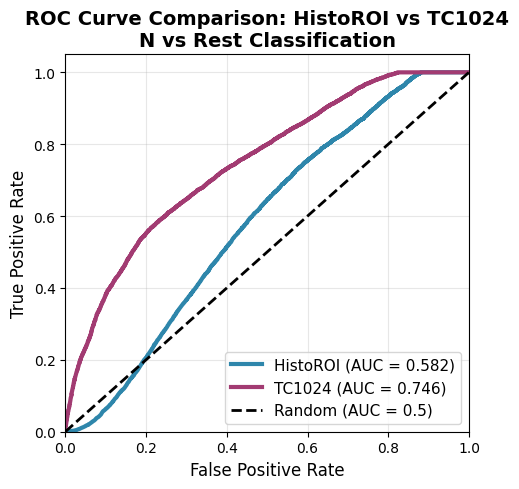

In [12]:
# Find common samples
common_indices = epi_histoROI_df.index.intersection(epi_TC1024_df.index)

print(f"HistoROI samples: {len(epi_histoROI_df)}")
print(f"TC1024 samples: {len(epi_TC1024_df)}")
print(f"Common samples: {len(common_indices)}")

histo_common = epi_histoROI_df.loc[common_indices]
tc1024_common = epi_TC1024_df.loc[common_indices]

# Prepare data
y_true = histo_common['Group'].map({'N': 1, 'Rest': 0}).values
y_histo = histo_common['Epithelial'].values
y_tc = tc1024_common['TC_epi'].values

# Calculate AUC
auc_histo = roc_auc_score(y_true, y_histo)
auc_tc = roc_auc_score(y_true, y_tc)

# DeLong test
z, p = delong_test(y_true, y_tc, y_histo)

print(f"\nHistoROI AUC: {auc_histo:.3f}")
print(f"TC1024 AUC: {auc_tc:.3f}")
print(f"AUC difference: {auc_tc - auc_histo:+.3f}")
print(f"DeLong test: z={z:.3f}, p={p:.4f}")
print(f"Significant: {'Yes' if p < 0.05 else 'No'}")

# ROC curves (common samples only)
y_true_histo = histo_common['Group'].map({'N': 1, 'Rest': 0}).values
y_scores_histo = histo_common['Epithelial'].values
y_true_tc = tc1024_common['Group'].map({'N': 1, 'Rest': 0}).values
y_scores_tc = tc1024_common['TC_epi'].values

fpr_histo, tpr_histo, _ = roc_curve(y_true_histo, y_scores_histo)
fpr_tc, tpr_tc, _ = roc_curve(y_true_tc, y_scores_tc)
roc_auc_histo = auc(fpr_histo, tpr_histo)
roc_auc_tc = auc(fpr_tc, tpr_tc)

plt.figure(figsize=(5, 5))
plt.plot(fpr_histo, tpr_histo, 
         color='#2E86AB', linewidth=3, 
         label=f'HistoROI (AUC = {roc_auc_histo:.3f})')
plt.plot(fpr_tc, tpr_tc, 
         color='#A23B72', linewidth=3, 
         label=f'TC1024 (AUC = {roc_auc_tc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, 
         label='Random (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison: HistoROI vs TC1024\nN vs Rest Classification', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(f"{basefolder}/BRACS_ROC_Comparison_HistoROI_vs_TC1024.pdf", 
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

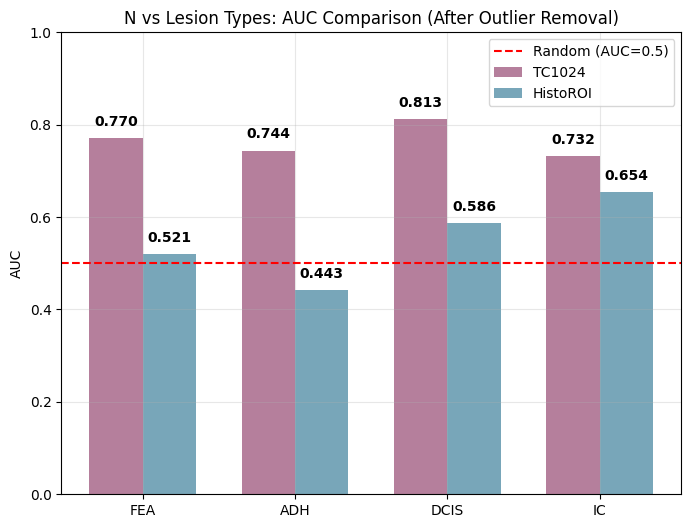

In [20]:
lesion_types = ['FEA', 'ADH', 'DCIS',  'IC']

auc_TC1024 = compute_auc(epi_TC1024_df, 'TC_epi', lesion_types)
auc_histoROI = compute_auc(epi_histoROI_df, 'Epithelial', lesion_types)

plt.figure(figsize=(8,6))
width = 0.35
x = range(len(lesion_types))

plt.bar([i - width/2 for i in x], auc_TC1024['AUC'], width=width, label='TC1024', color='#964972', alpha=0.7)
plt.bar([i + width/2 for i in x], auc_histoROI['AUC'], width=width, label='HistoROI', color='#3F819C', alpha=0.7)

plt.axhline(0.5, color='red', linestyle='--', label='Random (AUC=0.5)')
plt.xticks(x, lesion_types)
plt.ylim(0, 1.0)
plt.ylabel('AUC')
plt.title('N vs Lesion Types: AUC Comparison (After Outlier Removal)')
plt.grid(True, alpha=0.3)
plt.legend()

for i, auc in enumerate(auc_TC1024['AUC']):
    plt.text(i - width/2, auc + 0.02, f'{auc:.3f}', ha='center', va='bottom', fontweight='bold')
for i, auc in enumerate(auc_histoROI['AUC']):
    plt.text(i + width/2, auc + 0.02, f'{auc:.3f}', ha='center', va='bottom', fontweight='bold')


plt.savefig(f"{basefolder}/BRACS_patch_ids_CenterSampling_sampled8000_TC1024_N_vs_Rest_AUCs_barplot.pdf",
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

### HistoROI CAM

In [ ]:
import os
import glob
import torch
import pandas as pd
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms, models
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import staintools

def crop_patch(image, x, y, patch_size=1024):
    return image.crop((x, y, x + patch_size, y + patch_size))

def Reinhard(img_arr, standard_img="/scratch/users/k21066795/NBT-Classifier/data/he.jpg"):
    target = staintools.read_image(standard_img)
    target = staintools.LuminosityStandardizer.standardize(target)
    normalizer = staintools.ReinhardColorNormalizer()
    normalizer.fit(target)
    img_to_transform = staintools.LuminosityStandardizer.standardize(img_arr)
    return normalizer.transform(img_to_transform)

def show_cam_on_image_viridis(img, mask):
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_VIRIDIS)
    heatmap = np.float32(heatmap) / 255
    cam = heatmap + np.float32(img)
    cam = cam / np.max(cam)
    return np.uint8(255 * cam)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [4]:
basefolder="/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTClassifier/npj_revision"
image_folder = '/scratch/prj/cb_normalbreast/prj_BreastAgeNet/WSIs/BRACS_ROI'
os.listdir(image_folder+'/train')

class_names = ['Epithelial', 'Stroma', 'Adipose', 'Artefact', 'Miscellaneous', 'Lymphocytes']
epithelial_idx = class_names.index('Epithelial')  

sampled_df = pd.read_csv(f"{basefolder}/BRACS_patch_ids_CenterSampling_sampled8000.csv")
N_df = sampled_df.loc[sampled_df['source'] == "N", :]
N_df

,patch_id,roi_id,source,x,y,size,center_x,center_y
32000,BRACS_760_N_8_896_430_1024,BRACS_760_N_8,N,896,430,1024,1408,942
32001,BRACS_1585_N_2_182_165_1024,BRACS_1585_N_2,N,182,165,1024,694,677
32002,BRACS_1945_N_21_324_529_1024,BRACS_1945_N_21,N,324,529,1024,836,1041
32003,BRACS_1937_N_6_217_0_1024,BRACS_1937_N_6,N,217,0,1024,729,512
32004,BRACS_1493_N_6_285_516_1024,BRACS_1493_N_6,N,285,516,1024,797,1028
...,...,...,...,...,...,...,...,...
39995,BRACS_1945_N_20_67_635_1024,BRACS_1945_N_20,N,67,635,1024,579,1147
39996,BRACS_300_N_14_9_206_1024,BRACS_300_N_14,N,9,206,1024,521,718
39997,BRACS_1900_N_2_797_395_1024,BRACS_1900_N_2,N,797,395,1024,1309,907
39998,BRACS_1945_N_6_308_897_1024,BRACS_1945_N_6,N,308,897,1024,820,1409


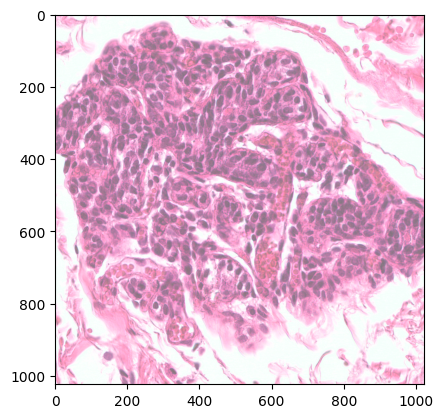

In [39]:
row = N_df.iloc[1, :]
patch_id = str(row['patch_id'])

roi_id = row['roi_id']
x, y = int(row['x']), int(row['y'])

# Find ROI image
image_paths = glob.glob(f"{image_folder}/*/*/{roi_id}.png")
image_path = image_paths[0]

# Load and process image
image = Image.open(image_path)
patch_image = crop_patch(image, x, y)
rgb_img = Reinhard(np.array(patch_image))
plt.imshow(rgb_img)

Predicted class: Epithelial (prob=0.963)
Epithelial prob: 0.963


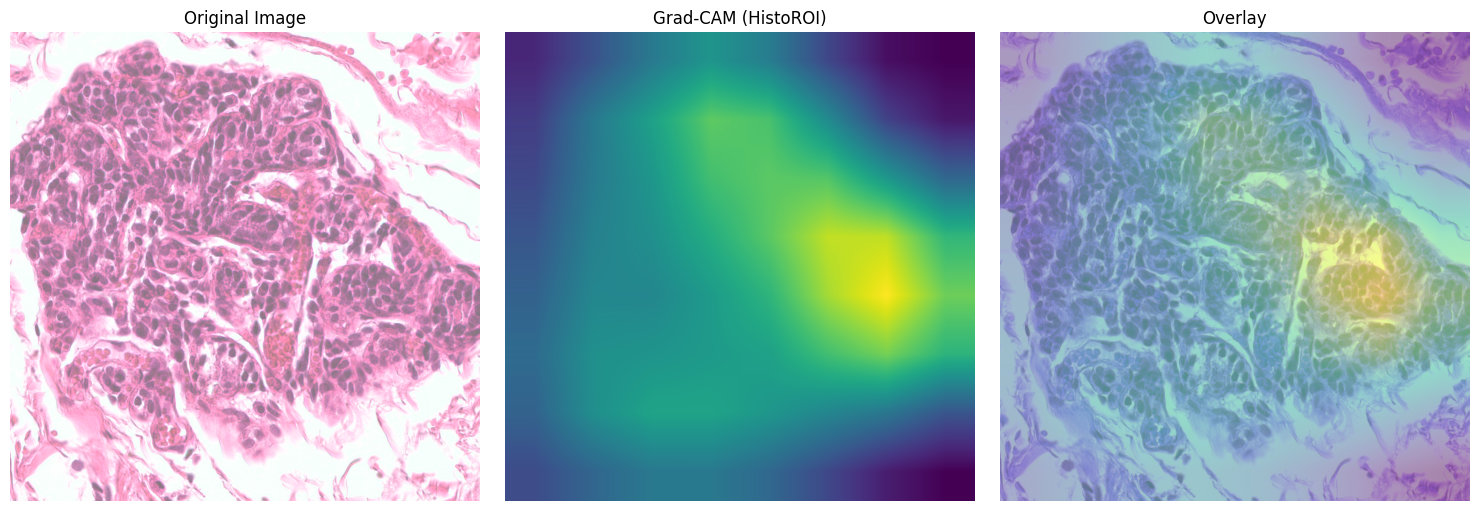

In [46]:
histoROI = "/scratch/prj/cb_normalbreast/prj_BreastAgeNet/CKPTs/histoROI_weights.pt"
model6 = models.resnet18().to(device)
model6.fc = torch.nn.Linear(512, 6).to(device)
model6.load_state_dict(torch.load(histoROI, map_location=device))
model6.eval()

base_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.ToTensor()
])

input_tensor = base_transform(Image.fromarray(rgb_img)).unsqueeze(0).to(device)
target_layers = [model6.layer4[-1]]
cam = GradCAM(model=model6, target_layers=target_layers)
grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]
grayscale_cam_resized = cv2.resize(grayscale_cam, (rgb_img.shape[1], rgb_img.shape[0]))

cam_heatmap_viridis = cv2.applyColorMap(np.uint8(255 * grayscale_cam_resized), cv2.COLORMAP_VIRIDIS)
visualization_viridis = show_cam_on_image_viridis(np.float32(rgb_img)/255.0, grayscale_cam_resized)

with torch.no_grad():
    pred = model6(input_tensor)
    prob = torch.nn.functional.softmax(pred, dim=1)
    pred_class = torch.argmax(prob, dim=1).item()
    print(f"Predicted class: {class_names[pred_class]} (prob={prob[0, pred_class]:.3f})")
    print(f"Epithelial prob: {prob[0, epithelial_idx]:.3f}")

plt.figure(figsize=(15,5))
plt.subplot(1, 3, 1)
plt.imshow(rgb_img)
plt.axis('off')
plt.title('Original Image')

plt.subplot(1, 3, 2)
plt.imshow(cam_heatmap_viridis[..., ::-1])  # BGR->RGB
plt.axis('off')
plt.title('Grad-CAM (HistoROI)')

plt.subplot(1, 3, 3)
plt.imshow(visualization_viridis[..., ::-1])  # BGR->RGB
plt.axis('off')
plt.title('Overlay')

plt.tight_layout()
plt.savefig(f"{basefolder}/BRACS_HistoROI_CAM.png", dpi=300)
plt.show()

### 1024px-based NBT-Classifier CAM

In [29]:
import tensorflow as tf
import numpy as np
import cv2
from PIL import Image
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import glob
import numpy as np
import staintools
import pandas as pd
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications.mobilenet import MobileNet, preprocess_input
from tensorflow.keras.layers import Resizing
from tensorflow.keras.utils import Sequence

def get_TC1024(weights, output_features=False):
    IMAGE_SIZE = (1024, 1024)
    NUM_CLASSES = 3
    initializer = tf.keras.initializers.GlorotNormal()
    # Define the base MobileNet model
    net = MobileNet(include_top=False, input_tensor=None, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
    x = net.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu', name='Dense_1', kernel_initializer=initializer)(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu', name='Dense_2', kernel_initializer=initializer)(x)
    feature_layer = x  # Save this layer for feature extraction
    output_layer = Dense(NUM_CLASSES, activation='softmax', name='Predictions')(x)
    # Create the model
    if output_features:
        # Create the model with two outputs: predictions and features
        net_final = Model(inputs=net.input, outputs=[output_layer, feature_layer], trainable=False)
    else:
        # Create the model with only predictions
        net_final = Model(inputs=net.input, outputs=output_layer, trainable=False)
    # Load the weights
    net_final.load_weights(weights)
    return net_final

    
def get_gradCAM_TC1024_rainbow(img, model, last_conv_layer_name, pred_index=None):
    """
    Generate Grad-CAM for NBT-Classifier (TC1024) model.
    Returns the raw CAM and the rainbow color heatmap (no overlay).
    """
    input_img = np.expand_dims(img, axis=0).astype(np.float32)
    input_img = tf.keras.applications.mobilenet.preprocess_input(input_img)

    # Grad-CAM model
    gradCAM_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute gradients
    with tf.GradientTape() as tape:
        last_conv_output, preds = gradCAM_model(input_img)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Compute CAM
    last_conv_output = last_conv_output[0]  # [H,W,C]
    CAM = last_conv_output @ pooled_grads[..., tf.newaxis]
    CAM = tf.squeeze(CAM)
    CAM = tf.maximum(CAM, 0) / (tf.reduce_max(CAM) + 1e-8)
    CAM = np.array(CAM)

    # Resize CAM to image size
    cam_resized = cv2.resize(CAM, (img.shape[1], img.shape[0]))

    # Apply rainbow colormap
    # cam_heatmap = cv2.applyColorMap((cam_resized*255).astype(np.uint8), cv2.COLORMAP_JET)
    cam_heatmap = cv2.applyColorMap((cam_resized*255).astype(np.uint8), cv2.COLORMAP_VIRIDIS)

    super_imposed_cam = cv2.addWeighted(img.astype("float32"), 0.3, cam_heatmap.astype("float32"), 0.8, 0.0)
    super_imposed_cam = super_imposed_cam.astype(np.uint8)

    return preds, CAM, cam_heatmap, super_imposed_cam

/tmp/ipykernel_118040/1450753936.py:25: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  net = MobileNet(include_top=False, input_tensor=None, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
/scratch/users/k21066795/conda/nbtclassifier/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1547']
Received: inputs=Tensor(shape=(1, 1024, 1024, 3))
  warnings.warn(msg)


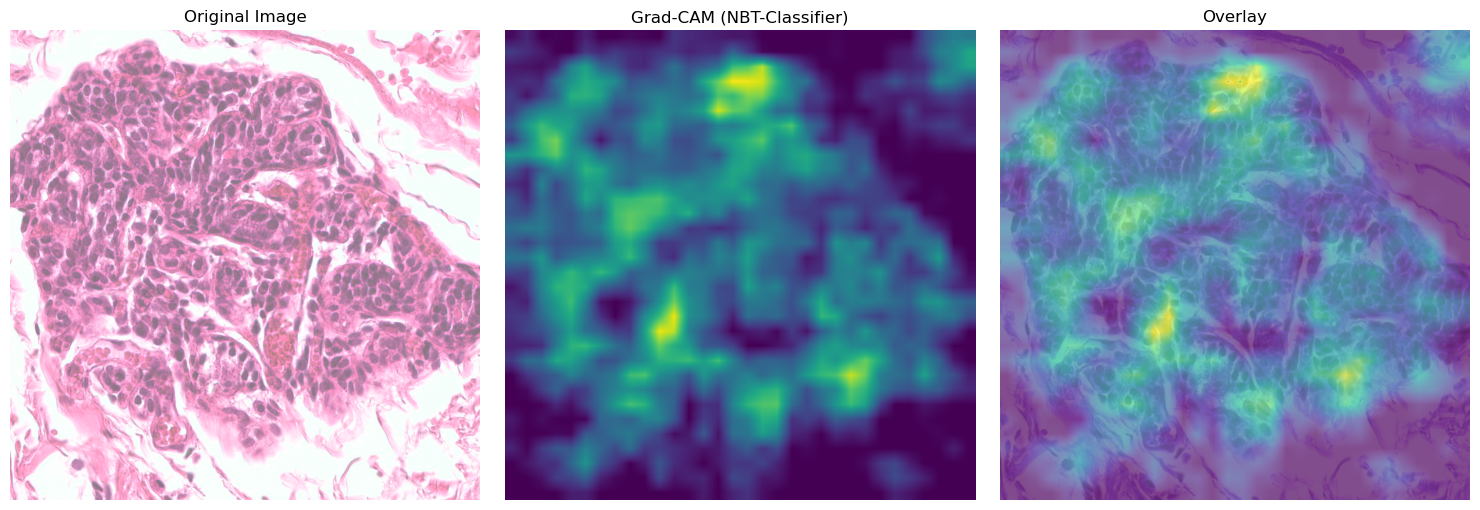

In [31]:
weights = '/scratch/prj/cb_histology_data/Siyuan/Docker_test/nbtclassifier/NBT-Classifier/data/TC_1024px.h5'
TC1024 = get_TC1024(weights, output_features=False)

img_path = "/scratch/users/k21066795/tmp_patch.png"
last_conv_layer_name = "conv_pw_13_relu"

# 生成 Grad-CAM
preds, CAM, cam_heatmap, super_imposed_cam = get_gradCAM_TC1024_rainbow(
    rgb_img, TC1024, last_conv_layer_name, pred_index=0
)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(rgb_img)
plt.axis('off')
plt.title('Original Image')

plt.subplot(1,3,2)
plt.imshow(cam_heatmap[..., ::-1])  # BGR->RGB
plt.axis('off')
plt.title('Grad-CAM (NBT-Classifier)')

plt.subplot(1,3,3)
plt.imshow(super_imposed_cam[..., ::-1])  # BGR->RGB
plt.axis('off')
plt.title('Overlay')

plt.tight_layout()
plt.savefig(f"{basefolder}/BRACS_NBTClassifier_CAM.png", dpi=300)
plt.show()